# Unidad 2: Aprendizaje Automático
## Vecinos Más Cercanos (KNN)
### Inteligencia Artificial — Lic. en Sistemas — FCAD/UNER

![Vecindario](https://raw.githubusercontent.com/CristianPacifico/ia-ls-fcad-uner/main/notebooks/ml/images/pexels-jesus-alfonso-536420752-36826026.jpg)

[Foto de Jesus  Alfonso](https://www.pexels.com/es-es/foto/vista-aerea-de-la-singular-arquitectura-de-metepec-36826026/)

---

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/CristianPacifico/ia-ls-fcad-uner/blob/main/notebooks/ml/24_KNN.ipynb)

## 🎯 ¿Qué vamos a aprender?

El algoritmo **K-Nearest Neighbors (KNN)** es uno de los más intuitivos del aprendizaje automático: clasifica una nueva muestra según las **k muestras más cercanas** en el espacio de features.

Al finalizar, vas a poder:
- ✅ Explicar el principio de funcionamiento de KNN
- ✅ Preprocesar datos categóricos para usarlos como features numéricas
- ✅ Entrenar y usar un clasificador KNN con `scikit-learn`
- ✅ Evaluar el impacto del hiperparámetro **k** en el rendimiento
- ✅ Usar **Pipelines** para combinar NCA + KNN y mejorar la clasificación

---

## 🧠 Marco Teórico

### 🗺️ ¿Cómo funciona KNN?

El algoritmo KNN es un método **basado en instancias** (*instance-based learning*). No aprende un modelo explícito durante el entrenamiento: simplemente **memoriza** todos los datos y, al predecir, busca los k vecinos más cercanos a la nueva muestra.

```
   Feature 2
   ↑
   | ●       ●
   |       ●            nueva muestra ✦
   | ●      ●           k=3 vecinos más cercanos
   | ○ ○ ○  ○ ○ ✦       Clase mayoritaria entre vecinos = predicción
   |     ○
   | ○        ○
   └───────────────── Feature 1

    ● = Clase A     ○ = Clase B
```

**Pasos del algoritmo:**
1. Calcular la distancia entre la nueva muestra y **todos** los puntos de entrenamiento
2. Seleccionar los **k puntos más cercanos**
3. Predecir la **clase mayoritaria** entre esos k vecinos

### 📐 Distancia Euclidiana

La métrica de distancia más común es la **distancia Euclidiana**:

$$d(p, q) = \sqrt{\sum_{i=1}^{n}(p_i - q_i)^2}$$

> ⚠️ **Por esto el preprocesamiento es crítico en KNN.** Si una feature tiene valores en miles (salario) y otra en decenas (edad), la primera dominará la distancia aunque no sea más informativa.

### 🔢 Elección del hiperparámetro k

| k pequeño | k grande |
|-----------|----------|
| Modelo más complejo | Modelo más simple |
| Mayor riesgo de overfitting | Mayor riesgo de underfitting |
| Frontera de decisión irregular | Frontera de decisión suave |
| Sensible al ruido | Más robusto al ruido |

> 💡 **Regla práctica:** usar `k = √n` (raíz cuadrada del número de muestras) como punto de partida, y ajustar con validación cruzada.

---

## 📦 Paso 1: Importar las Librerías

In [14]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn import preprocessing, datasets, metrics
from sklearn.neighbors import KNeighborsClassifier, NeighborhoodComponentsAnalysis
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

print('✅ Librerías importadas correctamente!')

✅ Librerías importadas correctamente!


## 🏷️ Paso 2: KNN con Datos Categóricos — El Problema del Clima

Antes de trabajar con KNN necesitamos **features numéricas**. Cuando los datos son categóricos (texto), aplicamos `LabelEncoder` para convertirlos.

**Problema:** dado el estado del tiempo y la temperatura, ¿se jugará un partido?

| Estado del tiempo | Temperatura | ¿Se juega? |
|-------------------|-------------|------------|
| Sunny             | Hot         | No         |
| Overcast          | Hot         | Yes        |
| Rainy             | Mild        | Yes        |
| ...               | ...         | ...        |

> 📌 **Referencia:** [DataCamp — K-Nearest Neighbor Classification](https://www.datacamp.com/community/tutorials/k-nearest-neighbor-classification-scikit-learn)

In [15]:
# Feature 1: Estado del tiempo
weather = ['Sunny', 'Sunny', 'Overcast', 'Rainy', 'Rainy', 'Rainy', 'Overcast',
           'Sunny', 'Sunny', 'Rainy', 'Sunny', 'Overcast', 'Overcast', 'Rainy']

# Feature 2: Temperatura
temp = ['Hot', 'Hot', 'Hot', 'Mild', 'Cool', 'Cool', 'Cool', 'Mild', 'Cool',
        'Mild', 'Mild', 'Mild', 'Hot', 'Mild']

# Etiqueta/variable objetivo
play = ['No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'No', 'Yes', 'Yes',
        'Yes', 'Yes', 'Yes', 'No']

# Codificar las variables categóricas a números
le = preprocessing.LabelEncoder()

weather_encoded = le.fit_transform(weather)
print('🌤️  Weather → codificado:')
print('  Clases:', list(le.classes_), '→', list(range(len(le.classes_))))
print('  Valores:', list(weather_encoded))

temp_encoded = le.fit_transform(temp)
print('\n🌡️  Temp → codificada:')
print('  Clases:', list(le.classes_), '→', list(range(len(le.classes_))))
print('  Valores:', list(temp_encoded))

label = le.fit_transform(play)
print('\n🎯 Play → codificado:')
print('  Clases:', list(le.classes_), '→', list(range(len(le.classes_))))
print('  Valores:', list(label))

🌤️  Weather → codificado:
  Clases: [np.str_('Overcast'), np.str_('Rainy'), np.str_('Sunny')] → [0, 1, 2]
  Valores: [np.int64(2), np.int64(2), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(2), np.int64(2), np.int64(1), np.int64(2), np.int64(0), np.int64(0), np.int64(1)]

🌡️  Temp → codificada:
  Clases: [np.str_('Cool'), np.str_('Hot'), np.str_('Mild')] → [0, 1, 2]
  Valores: [np.int64(1), np.int64(1), np.int64(1), np.int64(2), np.int64(0), np.int64(0), np.int64(0), np.int64(2), np.int64(0), np.int64(2), np.int64(2), np.int64(2), np.int64(1), np.int64(2)]

🎯 Play → codificado:
  Clases: [np.str_('No'), np.str_('Yes')] → [0, 1]
  Valores: [np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0)]


In [16]:
# Combinar las dos features en una lista de pares (weather, temp)
features = list(zip(weather_encoded, temp_encoded))
print('📦 Features combinadas (weather_encoded, temp_encoded):')
print(features[:5])

# Crear y entrenar el modelo KNN con k=3
model_knn_clima = KNeighborsClassifier(n_neighbors=3)
model_knn_clima.fit(features, label)

print('\n✅ Modelo KNN entrenado (k=3)')

# Predecir para: Overcast (0) + Mild (2)
# Codificación de weather: Overcast=0, Rainy=1, Sunny=2
# Codificación de temp:    Cool=0,  Hot=1,  Mild=2
prediccion = model_knn_clima.predict([[0, 2]])  # Overcast + Mild
clase = 'Yes' if prediccion[0] == 1 else 'No'
print(f'\n🔮 Predicción para (Overcast, Mild): ¿Se juega? → {clase}')

📦 Features combinadas (weather_encoded, temp_encoded):
[(np.int64(2), np.int64(1)), (np.int64(2), np.int64(1)), (np.int64(0), np.int64(1)), (np.int64(1), np.int64(2)), (np.int64(1), np.int64(0))]

✅ Modelo KNN entrenado (k=3)

🔮 Predicción para (Overcast, Mild): ¿Se juega? → Yes


## 🍷 Paso 3: KNN en el Dataset Wine — ¿Cuántos vecinos usar?

El dataset **Wine** de scikit-learn contiene 178 muestras de vinos italianos de 3 productores distintos, caracterizadas por 13 propiedades químicas (alcohol, acidez, color, etc.).

Vamos a comparar el rendimiento de KNN con distintos valores de **k** para entender su impacto.

In [17]:
# Cargar el dataset Wine
wine = datasets.load_wine()
X, y = wine.data, wine.target

print('📋 Información del dataset Wine:')
print(f'  Features ({len(wine.feature_names)}): {wine.feature_names}')
print(f'  Clases   ({len(wine.target_names)}): {list(wine.target_names)}')
print(f'  Forma de los datos: {wine.data.shape}')
print(f'  Forma del target:   {wine.target.shape}')
print('\n🔢 Primeras 3 muestras:')
print(wine.data[:3])

📋 Información del dataset Wine:
  Features (13): ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
  Clases   (3): [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]
  Forma de los datos: (178, 13)
  Forma del target:   (178,)

🔢 Primeras 3 muestras:
[[1.423e+01 1.710e+00 2.430e+00 1.560e+01 1.270e+02 2.800e+00 3.060e+00
  2.800e-01 2.290e+00 5.640e+00 1.040e+00 3.920e+00 1.065e+03]
 [1.320e+01 1.780e+00 2.140e+00 1.120e+01 1.000e+02 2.650e+00 2.760e+00
  2.600e-01 1.280e+00 4.380e+00 1.050e+00 3.400e+00 1.050e+03]
 [1.316e+01 2.360e+00 2.670e+00 1.860e+01 1.010e+02 2.800e+00 3.240e+00
  3.000e-01 2.810e+00 5.680e+00 1.030e+00 3.170e+00 1.185e+03]]


Vamos a buscar el número adecuado de vecinos a considerar, realizando una búsqueda en una grilla de hiperparámetros.

🏆 Mejor k (CV-5): 29  →  Accuracy = 0.7197


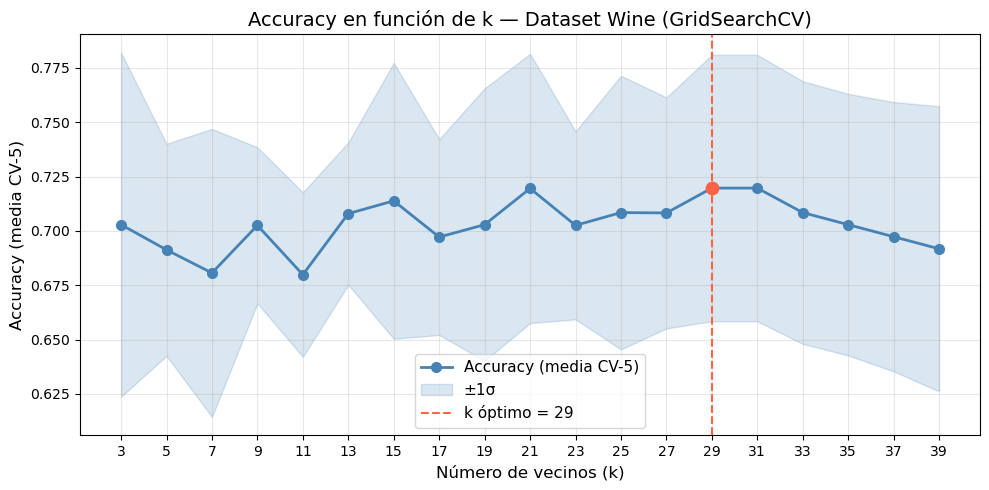

💡 La banda sombreada muestra ±1σ entre folds: una banda estrecha indica un modelo estable.
   GridSearchCV con CV-5 ofrece una estimación más robusta que un único split test.


In [19]:
from sklearn.model_selection import GridSearchCV
# Explorar la accuracy para un rango más amplio de k mediante GridSearchCV
k_values = list(range(3, 40, 2)) # Nros impares a partir de 3 hasta 39
param_grid_knn = {'n_neighbors': k_values}

gs_knn = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid_knn,
    scoring='accuracy',
    cv=5,
    verbose=0
)
gs_knn.fit(X, y)

accuracies = gs_knn.cv_results_['mean_test_score']
stds       = gs_knn.cv_results_['std_test_score']
mejor_k    = gs_knn.best_params_['n_neighbors']
mejor_acc  = gs_knn.best_score_

print(f'🏆 Mejor k (CV-5): {mejor_k}  →  Accuracy = {mejor_acc:.4f}')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_values, accuracies, 'o-', color='steelblue', linewidth=2, markersize=7,
        label='Accuracy (media CV-5)')
ax.fill_between(k_values,
                accuracies - stds,
                accuracies + stds,
                alpha=0.2, color='steelblue', label='±1σ')
ax.axvline(x=mejor_k, color='tomato', linestyle='--', linewidth=1.5,
           label=f'k óptimo = {mejor_k}')
ax.scatter([mejor_k], [mejor_acc], color='tomato', zorder=5, s=80)
ax.set_xlabel('Número de vecinos (k)', fontsize=12)
ax.set_ylabel('Accuracy (media CV-5)', fontsize=12)
ax.set_title('Accuracy en función de k — Dataset Wine (GridSearchCV)', fontsize=14)
ax.legend(fontsize=11)
ax.set_xticks(k_values)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'💡 La banda sombreada muestra ±1σ entre folds: una banda estrecha indica un modelo estable.')
print(f'   GridSearchCV con CV-5 ofrece una estimación más robusta que un único split test.')


## 🔬 Paso 4: NCA + KNN — Pipeline para Mejorar la Clasificación

### ¿Qué es NCA (Neighborhood Components Analysis)?

**NCA** es un algoritmo de aprendizaje de métricas (*metric learning*) que aprende una **transformación lineal del espacio de features** para maximizar la precisión de KNN.

En lugar de usar la distancia Euclidiana en el espacio original, NCA aprende **qué dimensiones y qué combinaciones** de features son más útiles para distinguir clases, y transforma los datos a ese nuevo espacio antes de aplicar KNN.

```
X (espacio original) ──── NCA ────► X' (espacio transformado) ──── KNN ────► clase
```

### 🔧 Pipeline + GridSearchCV

Un **Pipeline** encadena transformadores y estimadores secuencialmente. Al combinarlo con `GridSearchCV`, los hiperparámetros del estimador se referencian con el prefijo del paso:

```
Pipeline([('nca', NCA), ('knn', KNN)])
   ↓
param_grid = {'knn__n_neighbors': [1, 2, ..., 20]}
   ↓
GridSearchCV busca el mejor k evaluando NCA.fit_transform + KNN con CV-5
```

Usamos el **mismo dataset Wine** y la misma división `X_train`/`X_test` del paso anterior para comparar directamente KNN solo vs NCA+KNN.

> 📌 **Referencia:** [scikit-learn — Neighborhood Components Analysis](https://scikit-learn.org/stable/modules/neighbors.html#neighborhood-components-analysis)


🏆 Mejor k para NCA+KNN (CV-5): 7  →  Accuracy = 0.7562
🏆 Mejor k para KNN solo (CV-5): 29     →  Accuracy = 0.7197


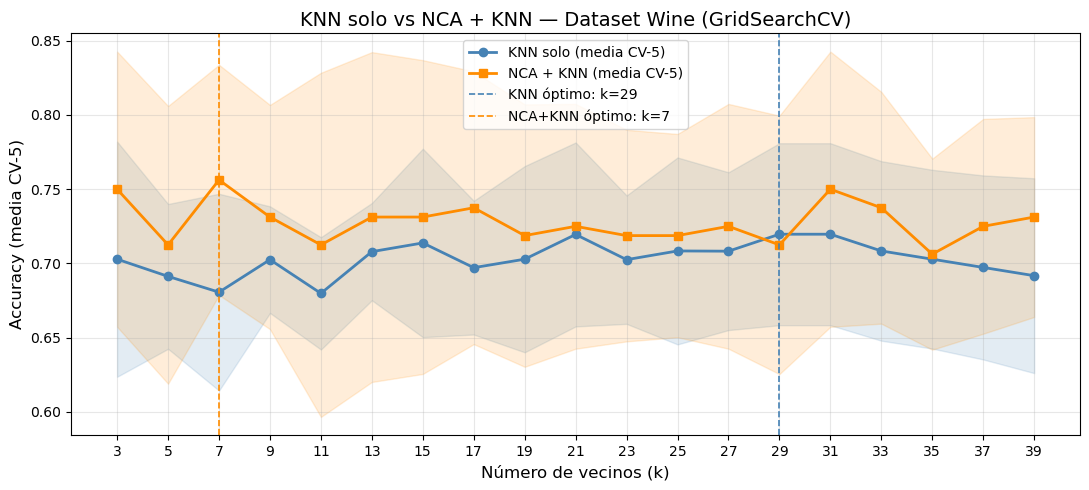


📊 Comparación final:
  KNN solo  — mejor k=29, Accuracy = 0.7197
  NCA + KNN — mejor k= 7, Accuracy = 0.7562
  🏆 NCA mejora la accuracy en 3.66 puntos porcentuales


In [20]:
# Pipeline NCA + KNN: buscar el mejor k con GridSearchCV
# En un Pipeline, los hiperparámetros se referencian como 'paso__parametro'
nca = NeighborhoodComponentsAnalysis(random_state=42)
knn = KNeighborsClassifier()
nca_pipe = Pipeline([('nca', nca), ('knn', knn)])

param_grid_nca = {'knn__n_neighbors': k_values}

gs_nca = GridSearchCV(
    estimator=nca_pipe,
    param_grid=param_grid_nca,
    scoring='accuracy',
    cv=5,
    verbose=0
)
gs_nca.fit(X_train, y_train)

acc_nca   = gs_nca.cv_results_['mean_test_score']
stds_nca  = gs_nca.cv_results_['std_test_score']
mejor_k_nca = gs_nca.best_params_['knn__n_neighbors']
mejor_acc_nca = gs_nca.best_score_

print(f'🏆 Mejor k para NCA+KNN (CV-5): {mejor_k_nca}  →  Accuracy = {mejor_acc_nca:.4f}')
print(f'🏆 Mejor k para KNN solo (CV-5): {mejor_k}     →  Accuracy = {mejor_acc:.4f}')

# --- Gráfico comparativo ---
fig, ax = plt.subplots(figsize=(11, 5))

# KNN solo
ax.plot(k_values, accuracies, 'o-', color='steelblue', linewidth=2, markersize=6,
        label='KNN solo (media CV-5)')
ax.fill_between(k_values, accuracies - stds, accuracies + stds,
                alpha=0.15, color='steelblue')

# NCA + KNN
ax.plot(k_values, acc_nca, 's-', color='darkorange', linewidth=2, markersize=6,
        label='NCA + KNN (media CV-5)')
ax.fill_between(k_values, acc_nca - stds_nca, acc_nca + stds_nca,
                alpha=0.15, color='darkorange')

# Óptimos
ax.axvline(x=mejor_k,     color='steelblue',  linestyle='--', linewidth=1.2,
           label=f'KNN óptimo: k={mejor_k}')
ax.axvline(x=mejor_k_nca, color='darkorange',  linestyle='--', linewidth=1.2,
           label=f'NCA+KNN óptimo: k={mejor_k_nca}')

ax.set_xlabel('Número de vecinos (k)', fontsize=12)
ax.set_ylabel('Accuracy (media CV-5)', fontsize=12)
ax.set_title('KNN solo vs NCA + KNN — Dataset Wine (GridSearchCV)', fontsize=14)
ax.legend(fontsize=10)
ax.set_xticks(k_values)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Resumen
print('\n📊 Comparación final:')
print('=' * 50)
print(f'  KNN solo  — mejor k={mejor_k:2d}, Accuracy = {mejor_acc:.4f}')
print(f'  NCA + KNN — mejor k={mejor_k_nca:2d}, Accuracy = {mejor_acc_nca:.4f}')
print('=' * 50)
if mejor_acc_nca > mejor_acc:
    print(f'  🏆 NCA mejora la accuracy en {(mejor_acc_nca - mejor_acc)*100:.2f} puntos porcentuales')
elif mejor_acc_nca == mejor_acc:
    print('  🤝 Ambos modelos alcanzan la misma accuracy')
else:
    print(f'  💡 KNN solo supera a NCA+KNN en {(mejor_acc - mejor_acc_nca)*100:.2f} pp en este dataset')


## 🎓 Resumen y Conclusiones

En este notebook aprendimos:

1. 🏷️ **Preprocesar datos categóricos** con `LabelEncoder` antes de aplicar KNN
2. 🗺️ **Entrenar KNN** con `KNeighborsClassifier` y predecir nuevas muestras
3. 🍷 **Comparar distintos valores de k** en el dataset Wine
4. 🔬 **Usar NCA + Pipeline** para aprender una métrica optimizada para KNN

### Puntos clave

- KNN es **sensible a la escala** → siempre estandarizar o normalizar las features
- Un **k pequeño** puede producir overfitting; un **k grande** puede perder detalles locales
- NCA aprende a **transformar el espacio** para maximizar la separabilidad de clases con KNN
- Los **Pipelines** encadenan transformaciones y estimadores para simplificar el flujo de trabajo

### 🚀 ¿Qué sigue?

- 📐 **SVM (Support Vector Machines)**: otro clasificador poderoso, también sensible a la escala
- 📊 **Validación cruzada (K-Fold)**: evaluación más robusta que train/test split
- 🔧 **StandardScaler + KNN**: probar KNN con datos estandarizados para ver la mejora

> 📚 **Referencias:**
> - [DataCamp — K-Nearest Neighbor Classification in Python](https://www.datacamp.com/community/tutorials/k-nearest-neighbor-classification-scikit-learn)
> - [scikit-learn — KNeighborsClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html)
> - [scikit-learn — Neighborhood Components Analysis](https://scikit-learn.org/stable/modules/neighbors.html#neighborhood-components-analysis)
> - [scikit-learn — Pipeline](https://scikit-learn.org/stable/modules/compose.html#combining-estimators)

---

© 2026 Cátedra Inteligencia Artificial — Lic. en Sistemas

Este notebook se distribuye bajo licencia [CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/).